In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)

In [5]:
n = 10000


In [6]:
data = pd.DataFrame({
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
})

In [7]:
print(data.info())
print(data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB
None
Patient_ID        0
Age               0
Gender            0
Blood_Pressure    0
Sugar_Level       0
Cholesterol       0
Heart_Rate        0
dtype: int64


In [8]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [9]:
print(data.describe())

print("Mean:\n", data.mean(numeric_only=True))
print("Median:\n", data.median(numeric_only=True))
print("Std Dev:\n", data.std(numeric_only=True))

        Patient_ID           Age  Blood_Pressure   Sugar_Level   Cholesterol  \
count  10000.00000  10000.000000    10000.000000  10000.000000  10000.000000   
mean    5000.50000     50.290400      129.668100    135.618200    224.568500   
std     2886.89568     17.588957       29.138093     37.843946     43.604943   
min        1.00000     20.000000       80.000000     70.000000    150.000000   
25%     2500.75000     35.000000      104.000000    103.000000    187.000000   
50%     5000.50000     50.000000      130.000000    136.000000    224.000000   
75%     7500.25000     66.000000      155.000000    169.000000    262.000000   
max    10000.00000     80.000000      180.000000    200.000000    300.000000   

         Heart_Rate  
count  10000.000000  
mean      89.890900  
std       17.483803  
min       60.000000  
25%       75.000000  
50%       90.000000  
75%      105.000000  
max      120.000000  
Mean:
 Patient_ID        5000.5000
Age                 50.2904
Blood_Pressure    

In [10]:
def classify_risk(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 180 or
        row["Cholesterol"] > 240):
        return "High"
    elif (row["Blood_Pressure"] > 120 or
          row["Sugar_Level"] > 140 or
          row["Cholesterol"] > 200):
        return "Medium"
    else:
        return "Low"

data["Risk_Level"] = data.apply(classify_risk, axis=1)
print(data["Risk_Level"].value_counts())

Risk_Level
High      6880
Medium    2402
Low        718
Name: count, dtype: int64


In [11]:
high_risk = data[data["Risk_Level"] == "High"]
print("High Risk Patients:\n", high_risk.head())

High Risk Patients:
    Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
0           1   58  Female             164          175          234   
1           2   71  Female             176           70          244   
4           5   62  Female             177           91          210   
6           7   80  Female              88          199          179   
9          10   77  Female             109          115          282   

   Heart_Rate Risk_Level  
0          77       High  
1          93       High  
4          90       High  
6          79       High  
9          69       High  


In [12]:
data["Age_Group"] = pd.cut(data["Age"], bins=[20,30,40,50,60,70,80],
                          labels=["20-30","30-40","40-50","50-60","60-70","70-80"])

print(data.groupby("Age_Group")["Blood_Pressure"].mean())
print(data.groupby("Gender")["Sugar_Level"].mean())
print(data["Risk_Level"].value_counts())

Age_Group
20-30    129.955300
30-40    130.670886
40-50    130.511515
50-60    128.573350
60-70    128.594132
70-80    129.962941
Name: Blood_Pressure, dtype: float64
Gender
Female    136.374271
Male      134.869652
Name: Sugar_Level, dtype: float64
Risk_Level
High      6880
Medium    2402
Low        718
Name: count, dtype: int64


/tmp/ipykernel_13310/2563817772.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby("Age_Group")["Blood_Pressure"].mean())


In [13]:
corr = data.corr(numeric_only=True)
print(corr)

                Patient_ID       Age  Blood_Pressure  Sugar_Level  \
Patient_ID        1.000000 -0.000225        0.009836     0.012334   
Age              -0.000225  1.000000       -0.008542    -0.001011   
Blood_Pressure    0.009836 -0.008542        1.000000    -0.018940   
Sugar_Level       0.012334 -0.001011       -0.018940     1.000000   
Cholesterol       0.007917 -0.015871        0.006170    -0.006722   
Heart_Rate       -0.002617  0.000218        0.004923     0.011292   

                Cholesterol  Heart_Rate  
Patient_ID         0.007917   -0.002617  
Age               -0.015871    0.000218  
Blood_Pressure     0.006170    0.004923  
Sugar_Level       -0.006722    0.011292  
Cholesterol        1.000000    0.004685  
Heart_Rate         0.004685    1.000000  


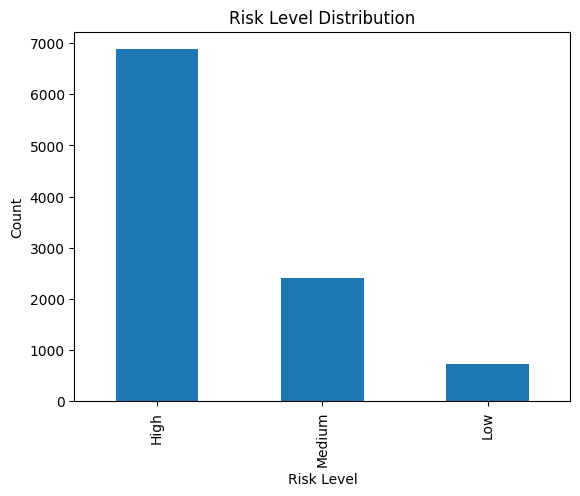

In [14]:
data["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

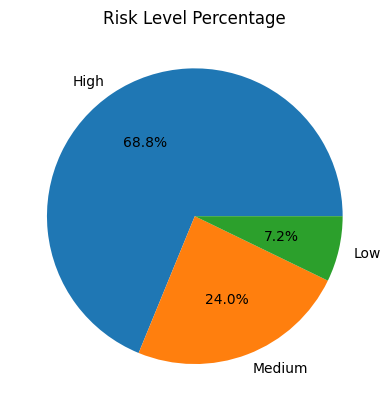

In [15]:
data["Risk_Level"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Risk Level Percentage")
plt.ylabel("")
plt.show()

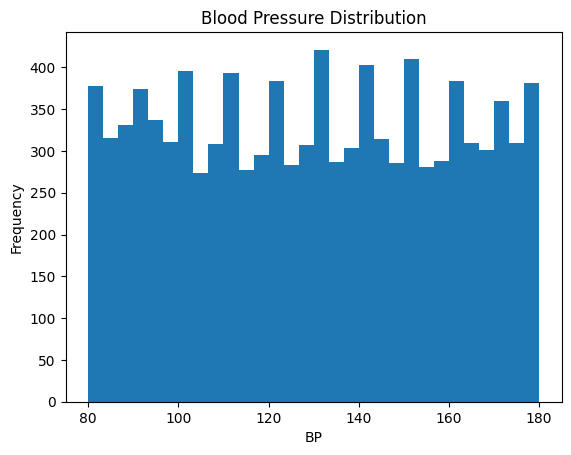

In [16]:
plt.hist(data["Blood_Pressure"], bins=30)
plt.title("Blood Pressure Distribution")
plt.xlabel("BP")
plt.ylabel("Frequency")
plt.show()

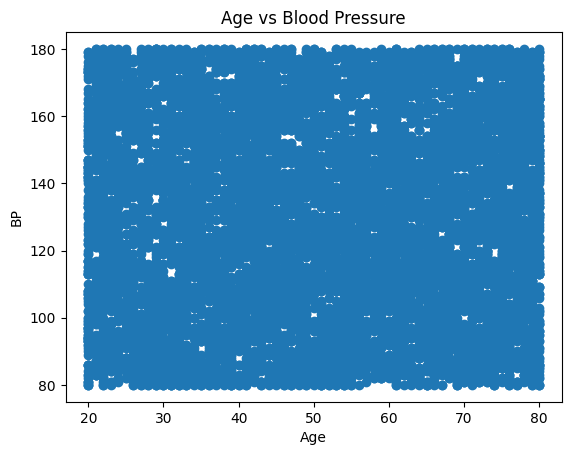

In [17]:
plt.scatter(data["Age"], data["Blood_Pressure"])
plt.title("Age vs Blood Pressure")
plt.xlabel("Age")
plt.ylabel("BP")
plt.show()

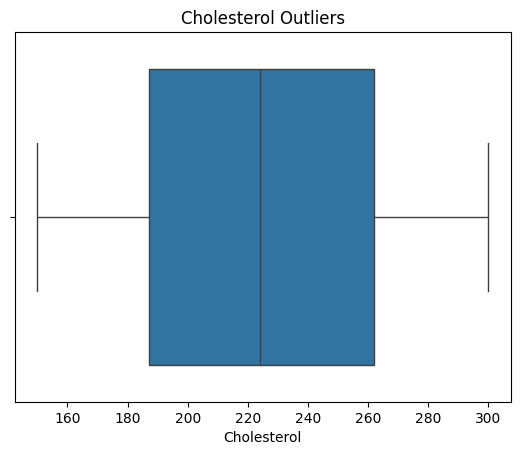

In [18]:
sns.boxplot(x=data["Cholesterol"])
plt.title("Cholesterol Outliers")
plt.show()

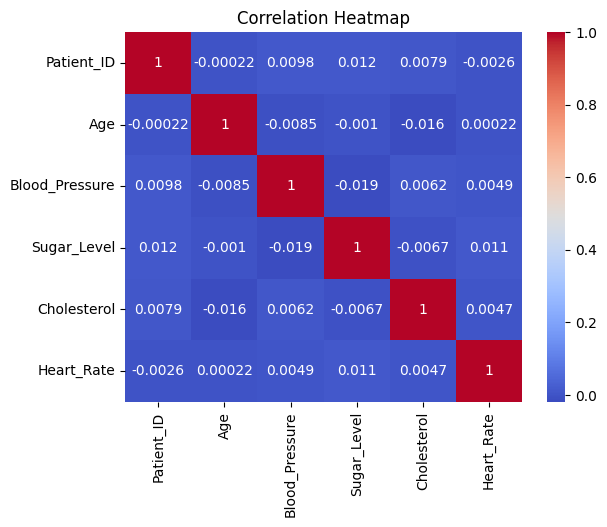

In [19]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
print("Average BP:", data["Blood_Pressure"].mean())
print("Average Sugar:", data["Sugar_Level"].mean())
print("High Risk Count:", len(high_risk))

Average BP: 129.6681
Average Sugar: 135.6182
High Risk Count: 6880
